[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PooryaBehnamie/bioimage-analysis-notebooks/blob/main/Notebook_2_From_Pixels_to_Puncta.ipynb)

# Notebook 2: From Pixels to Puncta

## The Preprocessing and Pre-computation Pipeline

Welcome Back!

In the last notebook, we got a taste for bioimage analysis by loading our first images. This time, we're going to dive deeper into the core computational principles that make it all work. We’ll learn what an image really is to a computer, how we change its properties (like color), and how we use those changes to find our first objects of interest, like ecDNA puncta.

#### Learning Goals:
- Master the differences between Matplotlib, scikit-image, and OpenCV for image I/O and display.
- Understand images as NumPy arrays, including data types and dynamic range.
- Navigate color spaces (RGB, Grayscale, HSV) and their applications in biology.
- Implement masking and overlays with both NumPy and OpenCV bitwise operations.
- Get a foundational understanding of object detection through Connected Components analysis.
- Set the stage for more advanced topics like filtering and deep learning.

## Setup
All packages are listed in the repository's `requirements.txt` / `environment.yml` (see README). On Google Colab everything needed is pre-installed.

In [1]:
# --- Setup: works locally and on Google Colab ---
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("data").exists():
    # On Colab, fetch the repository so the example data is available
    !git clone -q https://github.com/PooryaBehnamie/bioimage-analysis-notebooks.git
    %cd bioimage-analysis-notebooks

DATA_DIR = Path("data")                      # example images shipped with the repo
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)   # anything we save goes here (git-ignored)

import matplotlib
matplotlib.rcParams["figure.dpi"] = 72       # keeps saved notebooks small; raise for sharper figures

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
from skimage import io, color, img_as_float, img_as_ubyte, filters, measure, morphology, restoration, data

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['image.cmap'] = 'gray'

import skimage, matplotlib
print("Python:    ", sys.version.split()[0])
print("skimage:   ", skimage.__version__)
print("matplotlib:", matplotlib.__version__)
print("OpenCV:    ", cv2.__version__)

Python:     3.11.15
skimage:    0.26.0
matplotlib: 3.10.9
OpenCV:     4.13.0


**The three libraries we use:**

- [**OpenCV**](https://opencv.org/): an open-source computer vision library optimized for speed, with a C++ backend. It provides low-level primitives such as filtering, morphology and connected components.
- [**scikit-image**](https://scikit-image.org/): a scientific image processing library built on NumPy and SciPy. It emphasizes correctness and readable APIs for labeling, region properties, color conversion, filtering and segmentation.
- [**Matplotlib**](https://matplotlib.org/): Python's foundational plotting library, used for displaying images (`imshow`), histograms and publication-ready figures.

### 1. Tiny Recap + Setup

**Q:** How do we get an image into Python and see it inline, and why are there so many ways to do it?

**A:** This is a common point of confusion for new students, and the answer lies in understanding the core philosophy of each library. In bioimage analysis, we often use a trio of powerful Python libraries for different jobs:

* **Matplotlib:** Think of Matplotlib as your go-to for plotting and visualization. Its `plt.imread()` function reads common formats (like PNGs) and often returns images as floating-point arrays in the `[0,1]` range. While great for plotting with its auto-normalization, this behavior can be a "gotcha" if you're trying to perform quantitative analysis on the raw pixel values. Always be mindful of the `vmin/vmax/norm` arguments in `plt.imshow` for accurate display of intensity ranges. For more, see the [Matplotlib image tutorial](https://matplotlib.org/stable/tutorials/images.html).

* **scikit-image (skimage):** This is the workhorse for scientific image analysis. `skimage.io.imread` is designed to be "dtype-preserving," meaning it reads 16-bit TIFFs as `uint16` arrays, which is crucial for microscopy images that contain a wide range of intensity values. The entire library is built around treating images as NumPy arrays with a focus on scientific accuracy, providing explicit tools for type conversions (`img_as_float`, `img_as_ubyte`) to prevent unexpected data loss or artifacts.

* **OpenCV (cv2):** This library is all about speed and performance. `cv2.imread` is optimized for computer vision operations and returns images in the BGR (Blue, Green, Red) format by default, rather than the standard RGB. This is a critical detail to remember, especially when visualizing images with Matplotlib, which expects RGB. You must use `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` to convert it correctly for display. OpenCV shines with its highly optimized C++ backend for tasks like labeling, morphology, and bitwise operations.

**When to use which?**

* **Matplotlib:** For quick visualization, generating publication-quality figures, and creating plots like histograms.
* **scikit-image:** For most of your core bioimage analysis pipeline, where preserving data type and scientific accuracy are paramount.
* **OpenCV:** When you need maximum performance for low-level, high-volume operations or for specific primitives like bitwise masking and connected components.

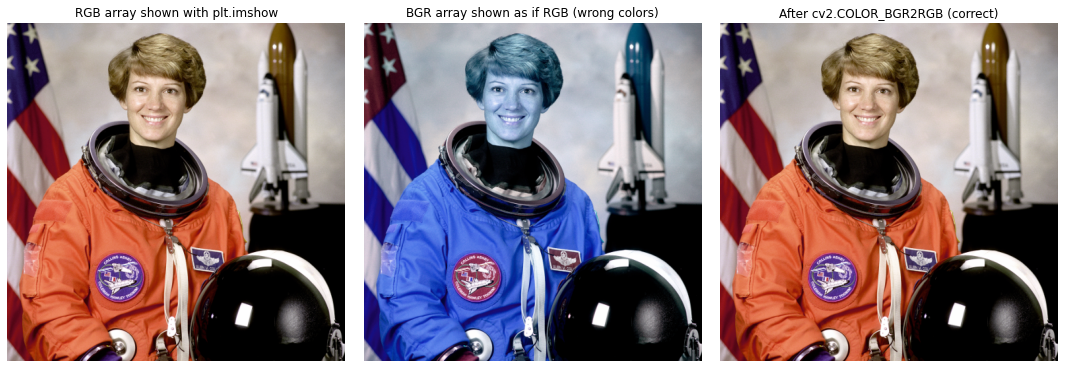

In [2]:
# We'll demo with scikit-image's built-in `astronaut` (RGB) and `coins` (grayscale) images.
from skimage.data import astronaut, coins

astro = astronaut()     # RGB uint8
coin = coins()          # grayscale uint8

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(astro); axs[0].set_title("RGB array shown with plt.imshow")

# OpenCV stores color images as BGR. If we forget to convert, red and blue are swapped:
astro_bgr = cv2.cvtColor(astro, cv2.COLOR_RGB2BGR)
axs[1].imshow(astro_bgr); axs[1].set_title("BGR array shown as if RGB (wrong colors)")

astro_rgb = cv2.cvtColor(astro_bgr, cv2.COLOR_BGR2RGB)
axs[2].imshow(astro_rgb); axs[2].set_title("After cv2.COLOR_BGR2RGB (correct)")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

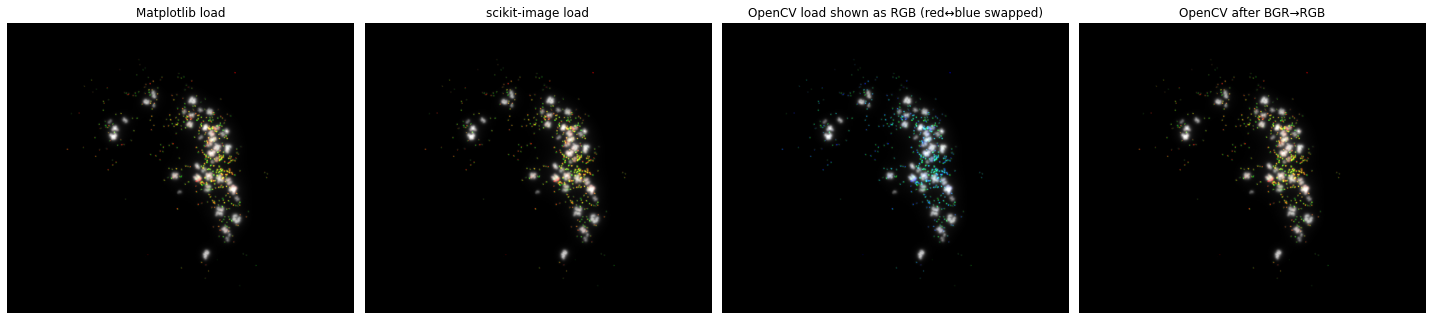

Same pixels from all three loaders? True


In [3]:
# Now the same with our FISH data (see Notebook 1 for what these files contain)
dapi_path = DATA_DIR / "fish_dapi.tif"
rgb_path  = DATA_DIR / "fish_rgb.tif"
mask_path = DATA_DIR / "fish_mia_mask.tif"

mat_img = plt.imread(rgb_path)                          # Matplotlib (uses Pillow under the hood)
sk_dapi = io.imread(dapi_path)                          # scikit-image (dtype-preserving)
sk_rgb  = io.imread(rgb_path)
cv_dapi = cv2.imread(str(dapi_path), cv2.IMREAD_UNCHANGED)
cv_rgb  = cv2.imread(str(rgb_path), cv2.IMREAD_UNCHANGED)  # BGR order!

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(mat_img);  axs[0].set_title("Matplotlib load")
axs[1].imshow(sk_rgb);   axs[1].set_title("scikit-image load")
axs[2].imshow(cv_rgb);   axs[2].set_title("OpenCV load shown as RGB (red↔blue swapped)")
axs[3].imshow(cv2.cvtColor(cv_rgb, cv2.COLOR_BGR2RGB)); axs[3].set_title("OpenCV after BGR→RGB")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

print("Same pixels from all three loaders?",
      np.array_equal(mat_img, sk_rgb) and np.array_equal(sk_rgb, cv_rgb[..., ::-1]))

### 2. What is an image to a computer? Arrays & bit-depth

**Q:** I can see an image, but what does a computer actually "see"?

**A:** To a computer, an image is not a picture; it’s a NumPy array. A grayscale image is a 2D array with a shape of `(height, width)`, where each element represents a pixel’s intensity. For color images, it’s a 3D array of `(height, width, channels)`. The number of channels is typically 3 for Red, Green, and Blue (or BGR for OpenCV).

The most important property of this array is its **data type (dtype)**, which determines its **dynamic range**—the total number of possible intensity values for each pixel.

* **`uint8`** (Unsigned 8-bit Integer): The most common format for web images. Pixels can have 2^8 = 256 values, from 0 to 255.
* **`uint16`** (Unsigned 16-bit Integer): The gold standard for scientific and microscopy images. It provides a much larger range of values (0 to 65,535), which is essential for capturing subtle intensity variations in low-light fluorescence images without loss of information.
* **`float`**: Floating-point data types (e.g., `float32`, `float64`) are used for mathematical operations where precision is required, often with values normalized to the `[0,1]` range.

**Why does `dtype` matter so much?**

Imagine you have a `uint8` image where the maximum intensity is 250. If you try to add 10 to every pixel, a naive operation would cause the value to "wrap around" from 255 back to 4 (250 + 10 = 260, and 260 − 256 = 4). This is a subtle but critical error known as **integer overflow**. By understanding `dtype`, you can correctly scale and normalize your images to avoid such pitfalls, a topic addressed in detail in the [scikit-image documentation](https://scikit-image.org/docs/stable/user_guide/data_types.html).

In [4]:
def describe(name, img):
    print(f"{name}: shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")

describe("DAPI (scikit-image)", sk_dapi)
describe("RGB  (scikit-image)", sk_rgb)

# Integer overflow in action: uint8 arithmetic wraps around
x = np.array([250], dtype=np.uint8)
print("\nuint8 250 + 10 =", (x + np.uint8(10))[0], " <- wrapped around!")
print("safe version    =", np.clip(x.astype(np.int16) + 10, 0, 255).astype(np.uint8)[0])

DAPI (scikit-image): shape=(2048, 2448), dtype=uint8, min=0, max=255
RGB  (scikit-image): shape=(2048, 2448, 3), dtype=uint8, min=0, max=255

uint8 250 + 10 = 4  <- wrapped around!
safe version    = 255


uint8: uint8 1 252
uint16: uint16 257 64764
float: float64 0.00392156862745098 0.9882352941176471


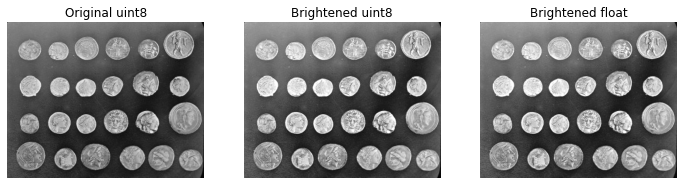

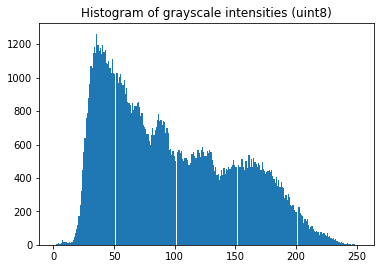

In [5]:
gray = coin.copy()  # uint8

# Make variants
u8  = gray.copy()
u16 = (gray.astype(np.uint16) * 257)   # expand to 16-bit
f   = img_as_float(gray)               # float in [0,1]

print("uint8:", u8.dtype, u8.min(), u8.max())
print("uint16:", u16.dtype, u16.min(), u16.max())
print("float:", f.dtype, f.min(), f.max())

# Brighten safely
u8_bright = np.clip(u8.astype(np.int16)+40, 0, 255).astype(np.uint8)
f_bright  = np.clip(f + 40/255.0, 0, 1.0)

fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(u8, cmap="gray"); axs[0].set_title("Original uint8"); axs[0].axis("off")
axs[1].imshow(u8_bright, cmap="gray"); axs[1].set_title("Brightened uint8"); axs[1].axis("off")
axs[2].imshow(f_bright, cmap="gray"); axs[2].set_title("Brightened float"); axs[2].axis("off")
plt.show()

# Histogram
plt.hist(u8.ravel(), bins=256)
plt.title("Histogram of grayscale intensities (uint8)")
plt.show()

### 3. Color Spaces (RGB ↔ Grayscale ↔ HSV) — and why convert?

**Q:** Why do we need to think about color spaces beyond the standard RGB?

**A:** While RGB is natural for display, we often need to transform it for specific analysis tasks. Different color spaces organize light information in different ways, which can be immensely useful in bioimaging.

* **RGB (Red, Green, Blue):** This is the device-native color space where each pixel's color is defined by the intensity of its red, green, and blue components. It’s perfect for creating visually stunning composites of multi-channel microscopy images, like overlaying DAPI (blue) with a red-tagged FISH probe. However, analyzing intensity in RGB is tricky because a change in brightness (Value) also changes the color mix (Hue and Saturation).

* **Grayscale:** This is the most common and fundamental space for analysis. It represents the intensity of light, from black (0) to white (255 for uint8). All core image processing operations like filtering, thresholding, and segmentation are most straightforwardly performed on single-channel grayscale images. For example, each fluorescent channel (e.g., DAPI, FITC, Texas Red) is typically acquired and analyzed as a separate grayscale image. `skimage.color.rgb2gray` computes a **luminance-weighted** sum (0.2125 R + 0.7154 G + 0.0721 B), which matches how bright colors look to the human eye. Note that this is a *display* convention: for fluorescence it silently gives the green channel ~10× the weight of blue.

* **HSV (Hue, Saturation, Value):** This is a powerful space for analysis. It separates the color information (Hue) and color intensity (Saturation) from the brightness (Value). The Value channel is essentially a grayscale version of the image.
 A key use case: If you have a multicolored stain but only care about the bright objects (e.g., bright probe spots of any color), you can convert the image to HSV and simply threshold on the V channel to isolate the bright features, regardless of their original color.

* **Lab (CIELAB):** While less common in fluorescence, Lab is a perceptually uniform color space where the L channel represents lightness, and the a and b channels represent color opposition. This is often preferred for rigorous colorimetry or in brightfield histology, where methods like color deconvolution are used to mathematically unmix different stains.

RGB image: (512, 512, 3) uint8 (0, 255)


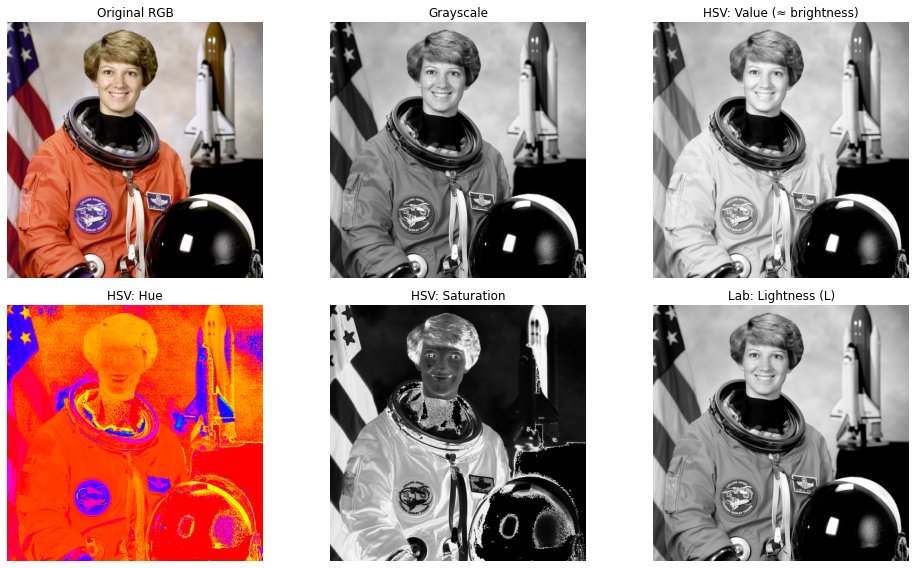

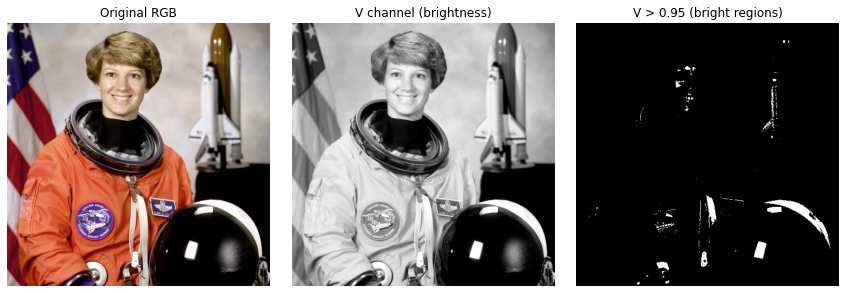

In [6]:
# --- Color Spaces (RGB ↔ Grayscale ↔ HSV ↔ Lab) ---

from skimage import data, color, img_as_float
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ----------------------------
# 3A. Load a demo RGB image
# ----------------------------
rgb = data.astronaut()         # uint8 RGB
rgb_float = img_as_float(rgb)  # Convert to float in [0,1] for skimage.color

print("RGB image:", rgb.shape, rgb.dtype, (int(rgb.min()), int(rgb.max())))

# ----------------------------
# 3B. Convert into other spaces
# ----------------------------
gray = color.rgb2gray(rgb_float)         # perceptual grayscale
hsv  = color.rgb2hsv(rgb_float)          # skimage expects float in [0,1]
lab  = cv2.cvtColor(rgb, cv2.COLOR_RGB2Lab)  # OpenCV Lab (uint8)

H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

# ----------------------------
# 3C. Visualize channels
# ----------------------------
fig, axs = plt.subplots(2, 3, figsize=(14,8))

axs[0,0].imshow(rgb)
axs[0,0].set_title("Original RGB")
axs[0,0].axis("off")

axs[0,1].imshow(gray, cmap="gray")
axs[0,1].set_title("Grayscale")
axs[0,1].axis("off")

axs[0,2].imshow(V, cmap="gray")
axs[0,2].set_title("HSV: Value (≈ brightness)")
axs[0,2].axis("off")

axs[1,0].imshow(H, cmap="hsv")
axs[1,0].set_title("HSV: Hue")
axs[1,0].axis("off")

axs[1,1].imshow(S, cmap="gray")
axs[1,1].set_title("HSV: Saturation")
axs[1,1].axis("off")

axs[1,2].imshow(lab[...,0], cmap="gray")
axs[1,2].set_title("Lab: Lightness (L)")
axs[1,2].axis("off")

plt.tight_layout()
plt.show()

# ----------------------------
# 3D. Practical Example: Thresholding Value channel
# ----------------------------
# Bright objects can be isolated by thresholding the Value channel
th = np.percentile(V, 98)   # take 98th percentile as a "bright" cutoff
mask_bright = V > th

fig, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].imshow(rgb)
axs[0].set_title("Original RGB")
axs[0].axis("off")

axs[1].imshow(V, cmap="gray")
axs[1].set_title("V channel (brightness)")
axs[1].axis("off")

axs[2].imshow(mask_bright, cmap="gray")
axs[2].set_title(f"V > {th:.2f} (bright regions)")
axs[2].axis("off")

plt.tight_layout()
plt.show()

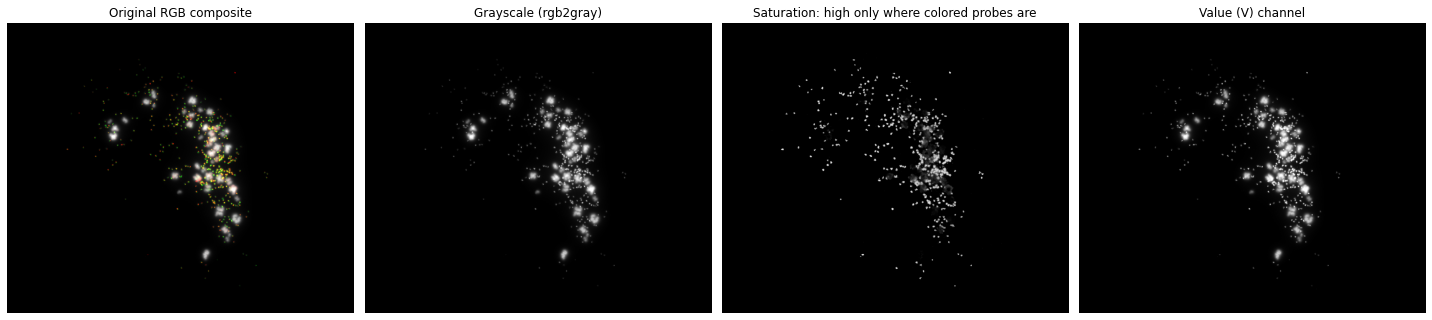

In [7]:
# The same conversions on our FISH composite
sk_gray = color.rgb2gray(sk_rgb)
sk_hsv  = color.rgb2hsv(sk_rgb)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sk_rgb);               axes[0].set_title('Original RGB composite')
axes[1].imshow(sk_gray, cmap='gray'); axes[1].set_title('Grayscale (rgb2gray)')
axes[2].imshow(sk_hsv[..., 1], cmap='gray'); axes[2].set_title('Saturation: high only where colored probes are')
axes[3].imshow(sk_hsv[..., 2], cmap='gray'); axes[3].set_title('Value (V) channel')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

Notice the **Saturation** channel: the gray chromosomes have almost no saturation, while the red and green probe spots are highly saturated. Color spaces can separate *what kind* of signal a pixel carries, not just how bright it is. The ecEnhance pipeline uses this idea to classify objects as ecDNA or chromosome.

### 4. Split/Merge Channels, Resizing, and Overlays

**Q:** How do we split channels, and how can we use a "mask" to focus on a specific region of interest?

**A:** Once we understand that an image is a NumPy array, these operations become a matter of manipulating array slices.

#### Splitting Channels

An RGB image is a 3D array (`H, W, 3`). You can access each channel using standard NumPy slicing: `red_channel = image[:, :, 0]`, `green_channel = image[:, :, 1]`, and `blue_channel = image[:, :, 2]`. This is the fundamental way to get at the raw intensity data for each channel.

Channel shapes: (512, 512) (512, 512) (512, 512)


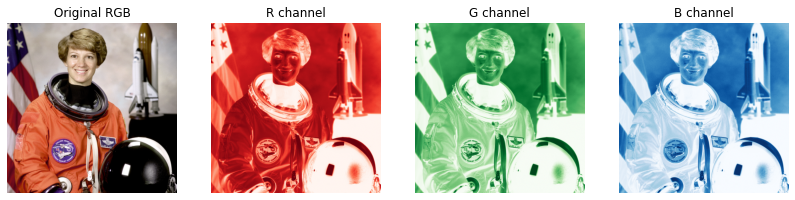

In [8]:
# --- Part 4: Split/Merge Channels, Masking, Resizing, and Overlays ---

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, color, filters, img_as_float, img_as_ubyte, transform

# ----------------------------
# 4A. Split & merge RGB channels
# ----------------------------
rgb_demo = data.astronaut()   # demo image (RGB, uint8)

R, G, B = rgb_demo[...,0], rgb_demo[...,1], rgb_demo[...,2]
print("Channel shapes:", R.shape, G.shape, B.shape)

# Merge back to RGB
rgb_merged = np.dstack([R, G, B])
assert np.allclose(rgb_demo, rgb_merged)  # sanity check

fig, axs = plt.subplots(1, 4, figsize=(14,4))
axs[0].imshow(rgb_demo); axs[0].set_title("Original RGB"); axs[0].axis("off")
axs[1].imshow(R, cmap="Reds"); axs[1].set_title("R channel"); axs[1].axis("off")
axs[2].imshow(G, cmap="Greens"); axs[2].set_title("G channel"); axs[2].axis("off")
axs[3].imshow(B, cmap="Blues"); axs[3].set_title("B channel"); axs[3].axis("off")
plt.show()

#### Masking and Overlays

A **mask** is a binary image (an array of `True/False` or `1/0` values) that defines a region of interest (ROI). We create a mask by setting a threshold: any pixel above a certain intensity is considered an object and gets a `True` value. We then use this mask to "select" pixels from the original image.

* **NumPy Masking:** The most intuitive way is with boolean array indexing: `masked_image = original_image.copy()`, then `masked_image[mask == False] = 0`. This sets all pixels outside the ROI to a value of 0 (black).

* **OpenCV Bitwise Operations:** OpenCV provides highly optimized bitwise operations. `cv2.bitwise_and(src1, src2, mask)` performs a logical AND operation on each pixel, but only on the pixels where the mask is non-zero. This is incredibly fast for high-volume operations.

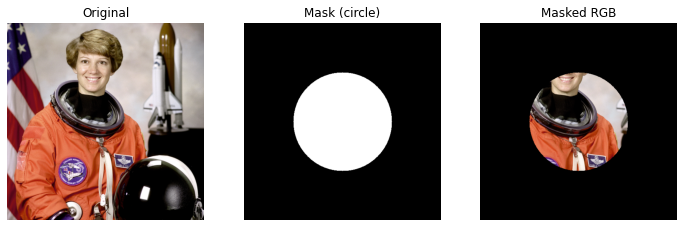

In [9]:
# ----------------------------
# 4B. Masking with NumPy vs OpenCV
# ----------------------------
# Make a simple circular mask
h, w = rgb_demo.shape[:2]
yy, xx = np.ogrid[:h, :w]
cy, cx, rad = h//2, w//2, min(h,w)//4
mask = (yy-cy)**2 + (xx-cx)**2 <= rad**2   # boolean mask

# NumPy masking
masked_np = rgb_demo.copy()
masked_np[~mask] = 0

# OpenCV masking (mask must be uint8 0/255)
mask_u8 = (mask*255).astype(np.uint8)
masked_cv = cv2.bitwise_and(rgb_demo, rgb_demo, mask=mask_u8)

fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(rgb_demo); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].imshow(mask, cmap="gray"); axs[1].set_title("Mask (circle)"); axs[1].axis("off")
axs[2].imshow(masked_cv); axs[2].set_title("Masked RGB"); axs[2].axis("off")
plt.show()

#### Resizing

When resizing images, the choice of interpolation method is critical.

* `cv2.INTER_NEAREST`: This method is best for resizing binary masks or labeled images, as it does not create new pixel values and preserves the original labels.
* `cv2.INTER_LINEAR` or `cv2.INTER_CUBIC`: These methods are better for resizing intensity images, as they use the values of surrounding pixels to compute a smoother result, preventing a "pixelated" appearance.

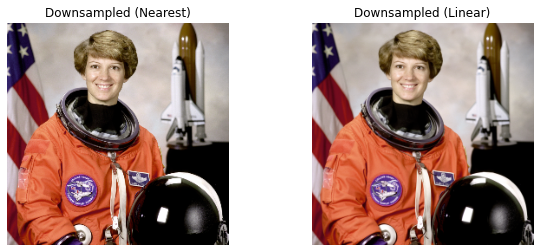

Nearest-neighbor: good for masks/labels (preserves integers)
Linear interpolation: good for intensity images (smoother)


In [10]:
# ----------------------------
# 4C. Resizing example
# ----------------------------
small_nn = cv2.resize(rgb_demo, (w//2, h//2), interpolation=cv2.INTER_NEAREST)
small_lin = cv2.resize(rgb_demo, (w//2, h//2), interpolation=cv2.INTER_LINEAR)

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].imshow(small_nn); axs[0].set_title("Downsampled (Nearest)"); axs[0].axis("off")
axs[1].imshow(small_lin); axs[1].set_title("Downsampled (Linear)"); axs[1].axis("off")
plt.show()

print("Nearest-neighbor: good for masks/labels (preserves integers)")
print("Linear interpolation: good for intensity images (smoother)")

### 4D) Example from our pipeline: restrict the analysis to a region of interest

**Q:** Why and how do we use DAPI to define where to look?

**A:** DAPI stains DNA. In our metaphase spread it lights up the condensed chromosomes, and more faintly the ecDNA themselves. Restricting analysis to the spread removes debris and background elsewhere on the slide.

There are two different ideas of "the DAPI mask", and the difference matters:

1. **Otsu threshold on DAPI** keeps only the **brightly stained chromosomes**.
2. **The expert region of interest** (in this dataset, DAPI pixels > 0) keeps the **whole spread**, including the space between chromosomes.

ecDNA are small and scattered *around* chromosomes. A mask that is too tight will throw real ecDNA away before detection even starts. Let's measure how much that matters, using the MIA predictions as a reference.

MIA-predicted ecDNA objects: 212
  kept by Otsu DAPI mask: 152
  kept by expert ROI:     212


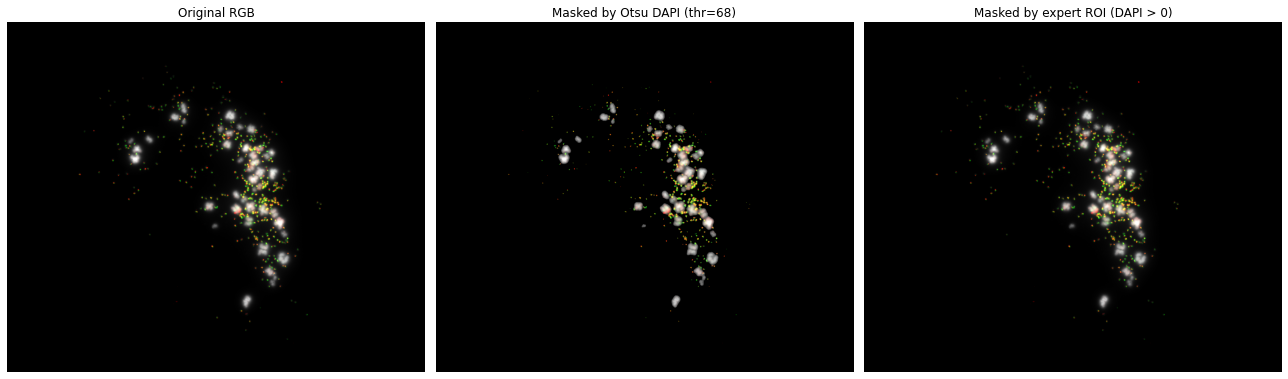

In [11]:
def mask_rgb(rgb_img, mask_bool):
    """Return a copy of an RGB image with pixels outside `mask_bool` set to black."""
    masked = rgb_img.copy()
    masked[~mask_bool] = 0
    return masked

dapi_img = sk_dapi
rgb_img  = sk_rgb
mia_mask = io.imread(mask_path) > 0        # MIA-predicted ecDNA pixels (reference, not ground truth)

# Option 1: Otsu threshold on DAPI -> chromosomes only
otsu_thr  = filters.threshold_otsu(dapi_img)
mask_otsu = dapi_img > otsu_thr

# Option 2: expert region of interest -> whole spread
mask_roi = dapi_img > 0

# How many MIA-predicted ecDNA objects fall inside each mask?
mia_labels = measure.label(mia_mask)
n_mia = mia_labels.max()
def n_objects_kept(mask):
    kept = np.unique(mia_labels[mask & mia_mask])
    return len(kept[kept > 0])

print(f"MIA-predicted ecDNA objects: {n_mia}")
print(f"  kept by Otsu DAPI mask: {n_objects_kept(mask_otsu)}")
print(f"  kept by expert ROI:     {n_objects_kept(mask_roi)}")

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(rgb_img);                          axs[0].set_title("Original RGB")
axs[1].imshow(mask_rgb(rgb_img, mask_otsu));     axs[1].set_title(f"Masked by Otsu DAPI (thr={otsu_thr:.0f})")
axs[2].imshow(mask_rgb(rgb_img, mask_roi));      axs[2].set_title("Masked by expert ROI (DAPI > 0)")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

**Take-home:** a preprocessing step that looks harmless (Otsu on DAPI) can silently remove a sizeable fraction of the very objects you want to count. Always check what a mask throws away. From here on we use the **expert ROI**.

### 5. What is Object Detection? (From a Computer's Point of View)

**Q:** What exactly is an "object" to a computer, and how do we find them?

**A:** To a computer, an "object" is simply a group of pixels that are somehow distinct from the background. In bioimaging, this could be a cell, a nucleus, or even a tiny bright spot like a FISH punctum.

#### Common Object Detection Approaches:

* **Connected Components (CC):** This is a classical, and very powerful, approach. The core idea is simple: after we convert an image to a binary mask (using thresholding), we label every contiguous blob of "object" pixels with a unique ID. We can then analyze each blob individually for its properties.

* **Blob/Spot Detectors (e.g., LoG):** These methods, like the Laplacian-of-Gaussian (LoG), are designed to find circular or elliptical blobs based on their intensity profile. The LoG filter, often called a "Mexican hat" filter, highlights regions of rapid intensity change. Finding where the filter's output crosses zero or peaks can precisely locate the center of a blob.

* **Learning-based Methods (Classical ML/Deep Learning):** These are more advanced methods that learn to find objects from examples. This can be classic machine learning on hand-crafted features or, more recently, deep learning models like U-Net, Cellpose, or StarDist, which perform semantic or instance segmentation. These are often more robust but require labeled data for training.

#### Hands-on: Connected Components with OpenCV vs. scikit-image

Connected Components analysis is a cornerstone of bioimage analysis. Let's compare two of the most popular implementations.

We start with a tiny synthetic example, then apply the same idea to the ecDNA probe signal.

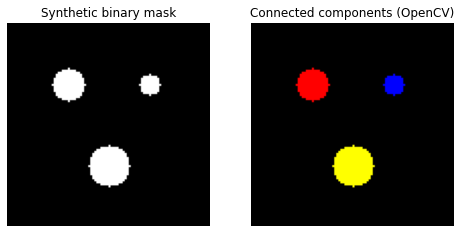

Found 3 objects


In [12]:
# --- Part 5: What is Object Detection? (From a Computer’s Point of View) ---

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import measure, color, filters, img_as_ubyte
import pandas as pd

# ----------------------------
# 5A. Mini synthetic demo (100x100 with 3 blobs)
# ----------------------------
h, w = 100, 100
img = np.zeros((h,w), dtype=np.uint8)
cv2.circle(img, (30,30), 8, 255, -1)   # blob 1
cv2.circle(img, (70,30), 5, 255, -1)   # blob 2
cv2.circle(img, (50,70), 10, 255, -1)  # blob 3

# Connected Components (OpenCV)
num_labels, labels_cv, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)
labels_color = color.label2rgb(labels_cv, bg_label=0)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("Synthetic binary mask"); ax[0].axis("off")
ax[1].imshow(labels_color); ax[1].set_title("Connected components (OpenCV)"); ax[1].axis("off")
plt.show()

print(f"Found {num_labels-1} objects")  # subtract 1 for background

#### Connected components on the FISH image

Which image should we threshold? Not the grayscale version of the composite: that would mix the gray chromosomes with the probe spots (the mistake warned about in Notebook 1). Instead, we isolate the **probe signal**:

- `R − B` removes the gray DAPI and leaves the red ERBB2 probe.
- `G − B` leaves the green MYC probe.
- Their pixel-wise maximum gives one "any probe" image.

We then compute Otsu's threshold **only from pixels inside the ROI**. If we included the millions of black pixels outside, they would drag the threshold down.

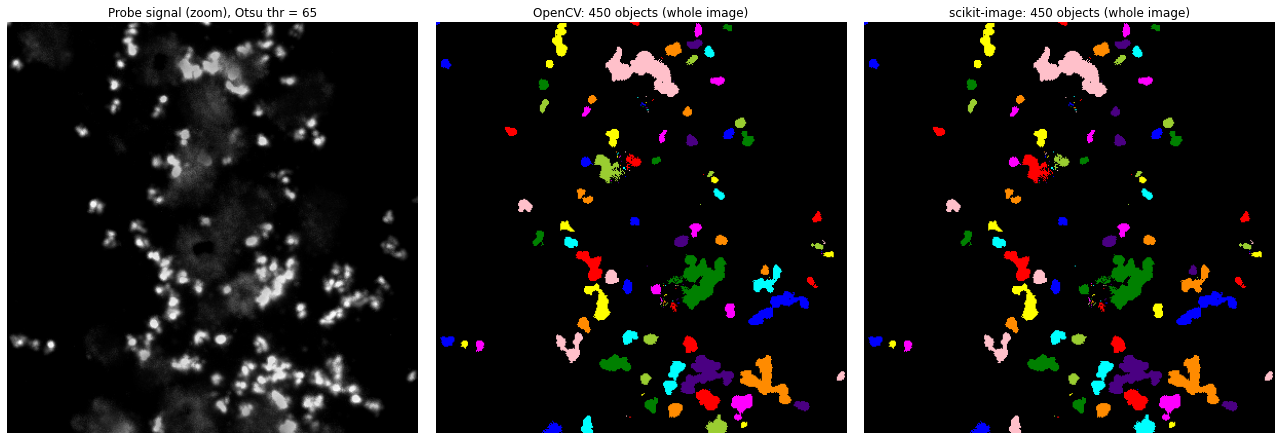

In [13]:
rgb16 = rgb_img.astype(np.int16)
red_probe   = np.clip(rgb16[..., 0] - rgb16[..., 2], 0, 255).astype(np.uint8)
green_probe = np.clip(rgb16[..., 1] - rgb16[..., 2], 0, 255).astype(np.uint8)
probe = np.maximum(red_probe, green_probe)
probe[~mask_roi] = 0

thr = filters.threshold_otsu(probe[mask_roi])      # threshold learned from ROI pixels only
binary_probe = (probe > thr).astype(np.uint8) * 255

# --- OpenCV connected components ---
num_labels, labels_cv, stats, centroids = cv2.connectedComponentsWithStats(binary_probe, connectivity=8)

# --- scikit-image connected components ---
labels_sk = measure.label(binary_probe > 0, connectivity=2)
props = measure.regionprops(labels_sk)

ys, xs = slice(700, 1100), slice(1250, 1650)       # zoom window for display
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(probe[ys, xs], cmap="gray");  axs[0].set_title(f"Probe signal (zoom), Otsu thr = {thr:.0f}")
axs[1].imshow(color.label2rgb(labels_cv[ys, xs], bg_label=0)); axs[1].set_title(f"OpenCV: {num_labels-1} objects (whole image)")
axs[2].imshow(color.label2rgb(labels_sk[ys, xs], bg_label=0)); axs[2].set_title(f"scikit-image: {len(props)} objects (whole image)")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

### Interpreting the Results

When we run connected components, each detected object comes with a few key measurements:

- **Centroid**: The center of mass of the object. This gives us a single coordinate we can use to locate the object in the image.  
- **Area**: The number of pixels that make up the object. Very small areas usually correspond to noise, while very large ones may be merged blobs. Filtering by area is often the first QC step. For ecDNA, single-pixel objects are almost certainly noise, while very large objects are usually several touching spots merged together.  
- **Bounding Box**: The smallest rectangle that contains the object. Bounding boxes are useful for drawing overlays, cropping regions of interest (ROIs), or feeding patches into later analysis (e.g., classification).

---

### Tabular Summary of Detected Objects

Besides visualizing objects, it’s often useful to **summarize their properties in a table**.  
With `scikit-image`, this is straightforward using `regionprops_table`, which outputs a dictionary of measurements that we can easily convert to a `pandas.DataFrame`.

This allows us to:
- Inspect numerical properties (e.g., area, centroid coordinates, bounding box).  
- Apply filters (e.g., keep objects above a certain size).  
- Integrate directly with analysis pipelines (saving results to CSV, plotting distributions, etc.).

,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3
0,1,5.0,294.800000,937.000000,294,936,297,939
1,2,2.0,324.000000,975.500000,324,975,325,977
2,3,5.0,332.200000,960.400000,331,960,334,962
3,4,65.0,350.753846,1608.461538,347,1604,356,1614
4,5,1.0,356.000000,1209.000000,356,1209,357,1210


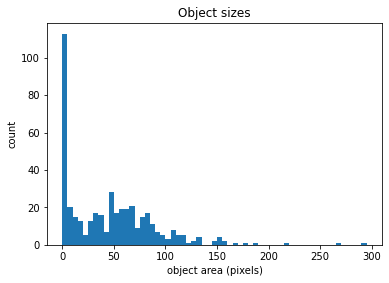

Kept 317 of 450 objects with area >= 10 px
For reference, MIA predicted 212 ecDNA objects in this image.


In [14]:
props_table = measure.regionprops_table(
    labels_sk, properties=('label', 'area', 'centroid', 'bbox'))
df = pd.DataFrame(props_table)
display(df.head())

# Look at the size distribution before choosing a cut-off
plt.hist(df['area'], bins=np.arange(0, 300, 5))
plt.xlabel("object area (pixels)"); plt.ylabel("count"); plt.title("Object sizes")
plt.show()

min_area = 10                                   # remove tiny specks
df_filt = df[df['area'] >= min_area].copy()
print(f"Kept {len(df_filt)} of {len(df)} objects with area >= {min_area} px")
print(f"For reference, MIA predicted {n_mia} ecDNA objects in this image.")

Our simple threshold-and-label detector and the MIA U-Net give different counts. That is expected. Some of the reasons:
- A red and a green spot that touch become **one** connected component.
- Clusters of ecDNA ("hubs") merge into large objects.
- Faint spots may fall below a single global threshold.

Neither number is "the truth". To know which is better we need **expert annotations** and proper metrics, which is the topic of Notebook 3.

👉 This table makes the results more **interpretable and reproducible**.  
Instead of just “seeing” objects, we can **measure and filter** them programmatically.

Next, let’s connect the numbers back to the image by drawing bounding boxes around the filtered objects.


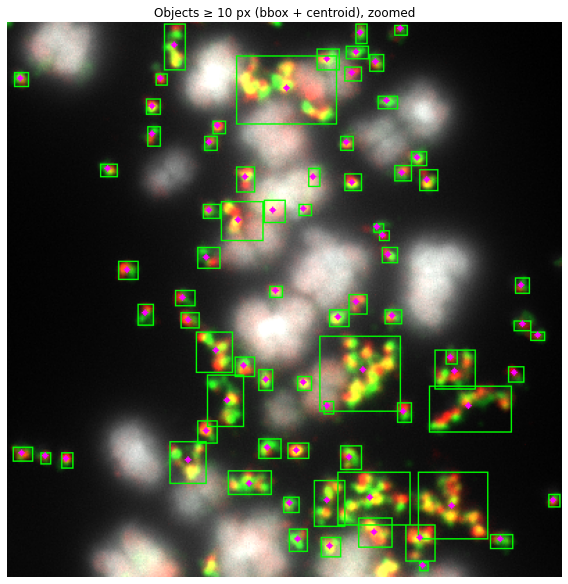

In [15]:
# Overlay bounding boxes (green) and centroids (magenta) on the zoomed composite
vis = rgb_img[ys, xs].copy()
for _, row in df_filt.iterrows():
    minr, minc, maxr, maxc = (int(row[f'bbox-{k}']) for k in range(4))
    # keep only objects inside the zoom window, shift coordinates into it
    if minr >= ys.start and maxr <= ys.stop and minc >= xs.start and maxc <= xs.stop:
        cv2.rectangle(vis, (minc - xs.start, minr - ys.start), (maxc - xs.start, maxr - ys.start), (0, 255, 0), 1)
        cv2.circle(vis, (int(row['centroid-1']) - xs.start, int(row['centroid-0']) - ys.start), 2, (255, 0, 255), -1)

plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title(f"Objects ≥ {min_area} px (bbox + centroid), zoomed")
plt.axis("off")
plt.show()


---

### OpenCV vs. scikit-image

- **OpenCV (`connectedComponentsWithStats`)**  
  - ✅ Very fast (C++ backend).  
  - ✅ Returns arrays with object statistics (`stats`) and centroids in one call.  
  - ✅ Bounding boxes are reported as `(x, y, width, height)` and areas as pixel counts.  
  - ⚠️ Coordinates follow `(x, y)` style (column, row), which can be confusing when plotting with NumPy/Matplotlib.

- **scikit-image (`label` + `regionprops`)**  
  - ✅ More Pythonic and flexible.  
  - ✅ `regionprops` returns a **rich set of measurements** for each object (area, centroid, bounding box, eccentricity, solidity, intensity stats, etc.).  
  - ✅ Uses `(row, col)` convention, which matches NumPy array indexing and is often easier to work with in scientific Python.  
  - ⚠️ Slightly slower than OpenCV, but integrates better with analysis workflows (e.g., easy conversion to `pandas` tables).

---

### Quick Comparison Table

| Feature / Property       | **OpenCV** (`connectedComponentsWithStats`) | **scikit-image** (`label` + `regionprops`) |
|--------------------------|---------------------------------------------|--------------------------------------------|
| **Speed**                | Very fast (C++ backend)                     | Slower (pure Python, NumPy-based)          |
| **Output style**          | Arrays (`stats`, `centroids`)              | Object-oriented (`RegionProperties`)       |
| **Coordinates**          | `(x, y)` → (col, row)                      | `(row, col)` → NumPy convention            |
| **Bounding box format**  | `[x, y, width, height]`                     | `(min_row, min_col, max_row, max_col)`     |
| **Available properties** | Area, centroid, bounding box                | Area, centroid, bounding box, eccentricity, solidity, intensity, etc. |
| **Ease of use in Python**| Lower (manual parsing)                      | Higher (direct attributes, Pandas-ready)   |

---

👉 **Take-home message:**  
Both methods are excellent. Use **OpenCV** when you want *raw speed and simplicity*. Use **scikit-image** when you need *richer measurements and easier integration* into Python data analysis pipelines.

### 6. Teaser: Gaussian Blur & Rolling-Ball Background

**Q:** What if our image is too noisy or has a messy background? How do we fix that?

**A:** Image preprocessing is key to a robust analysis pipeline. Even before we threshold an image, we often need to clean it up.

* **Gaussian Blur:** This is a powerful, linear filter that smooths an image by convolving it with a Gaussian kernel. It's a great way to reduce high-frequency noise and, importantly, approximates the natural blurring of a microscope's optics, known as the **Point Spread Function (PSF)**. A small Gaussian blur (e.g., sigma=1-2 pixels) can often make thresholding much more stable.

* **Rolling-Ball Background Subtraction:** This is a nonlinear, morphological method used to remove smooth, uneven background illumination while preserving small, bright objects. The algorithm simulates a "ball" rolling under the image surface to estimate the background intensity, which is then subtracted from the original image. This is particularly useful for fluorescence images with non-uniform illumination.

We will explore these powerful preprocessing techniques, and how they can be used to improve object detection, in Notebook 3.

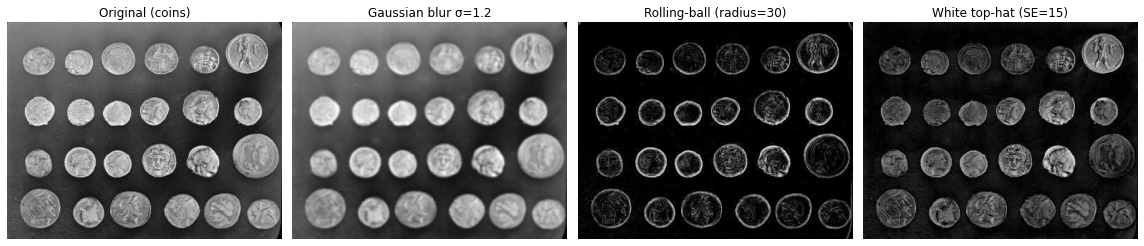

In [16]:
# --- Part 6: Teaser — Gaussian Blur & Rolling-Ball Background ---

from skimage import restoration, filters, morphology, img_as_float
import matplotlib.pyplot as plt

# Use demo grayscale image (coins) to illustrate
demo = img_as_float(data.coins())  # stand-in for fluorescence channel

# Gaussian blur (σ=1.2 pixels)
blurred = filters.gaussian(demo, sigma=1.2)

# Rolling-ball background subtraction
bg = restoration.rolling_ball(demo, radius=30)
corrected = np.clip(demo - bg, 0, 1)

# White top-hat (another background correction method, for comparison)
wth = morphology.white_tophat(demo, morphology.disk(15))

fig, axs = plt.subplots(1,4, figsize=(16,4))
axs[0].imshow(demo, cmap="gray"); axs[0].set_title("Original (coins)"); axs[0].axis("off")
axs[1].imshow(blurred, cmap="gray"); axs[1].set_title("Gaussian blur σ=1.2"); axs[1].axis("off")
axs[2].imshow(corrected, cmap="gray"); axs[2].set_title("Rolling-ball (radius=30)"); axs[2].axis("off")
axs[3].imshow(wth, cmap="gray"); axs[3].set_title("White top-hat (SE=15)"); axs[3].axis("off")
plt.tight_layout(); plt.show()

## Reflection — What did we learn?

- Reading images “three ways” helps anticipate **dtype, range, and BGR vs RGB quirks**.  
- Images are arrays; **dtype & dynamic range** matter.  
- **Color spaces** help separate intensity from hue/saturation.  
- **Masks** focus analysis on biological ROIs (e.g., nuclei).  
- **Connected Components** = the computer’s first object detector.  
- **Preprocessing** (blur, background correction) improves detection.  

## References

- Harris, C.R. et al. (2020). Array programming with NumPy. *Nature* 585:357–362.
- Hunter, J.D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering* 9:90–95.
- van der Walt, S. et al. (2014). scikit-image: image processing in Python. *PeerJ* 2:e453.
- Bradski, G. (2000). The OpenCV Library. *Dr. Dobb's Journal of Software Tools*.
- Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Trans. Systems, Man, and Cybernetics* 9:62–66.
- Sternberg, S.R. (1983). Biomedical image processing. *Computer* 16:22–34. (Rolling-ball background subtraction.)
- Goble, K. et al. (2025). Leveraging AI to automate detection and quantification of extrachromosomal DNA to decode drug responses. *Frontiers in Pharmacology* 15:1516621. (MIA predictions, example data context.)

---

## What's Next?

In **Notebook 3**, we'll:
- Connect microscope optics (the point spread function) to why spots look like Gaussian blobs
- Systematically apply **preprocessing** (Gaussian blur, rolling ball, top-hat) and **morphology**
- Detect spots with **LoG**, split touching objects with **watershed**, and score detections against **ground truth**
- Train a small **U-Net** on synthetic spots and compare it with LoG

> Questions for discussion: *When does LoG miss objects? How sensitive is connected components to the threshold? How does background removal change FP vs FN?*

## 🧪 Exercises (Try It Yourself!)

Worked solutions are in **Notebook 2B**.

1. **Image I/O practice**
   - Load `fish_rgb.tif` and `fish_dapi.tif` with all three libraries: `plt.imread`, `skimage.io.imread`, and `cv2.imread`.
   - Compare the shapes, dtypes, intensity ranges and channel order.

2. **Array inspection**
   - Take the DAPI image and print its `.shape`, `.dtype`, `.min()`, `.max()`.
   - Convert it to `uint16` and `float`, then brighten each **safely** (no overflow).
   - Plot histograms of the intensity values (inside the ROI only!).

3. **Color spaces**
   - Convert the FISH composite into **Grayscale** and **HSV**.
   - Plot the individual H, S, and V channels.
   - Threshold the **S** channel instead of V. What does it pick out, and why?

4. **Masks and overlays**
   - Create a nuclear/chromosome mask from DAPI with Otsu's threshold.
   - Use **NumPy masking** and **`cv2.bitwise_and`** to keep only masked pixels, and check both give identical results.
   - Draw the mask outline on top of the RGB image.

5. **Connected components**
   - Detect **red (ERBB2)** and **green (MYC)** spots *separately* with connected components.
   - Compare OpenCV and scikit-image object counts and areas.
   - Filter out blobs smaller than 10 pixels. How many ERBB2 vs MYC spots remain?

---

💡 *Tip:* Save intermediate results to the `outputs/` folder with `io.imsave` (scikit-image) or `cv2.imwrite` (OpenCV) to build your own "mini-pipeline".

---

### Acknowledgements

This notebook was prepared with the assistance of AI tools (ChatGPT, Grok, Gemini and Claude), which were used to help draft, edit, test and refine the code and explanatory text. Final responsibility for scientific accuracy, structure and educational content rests with the author.

Example FISH data: Brunk Lab, [ecEnhance](https://github.com/Brunk-Lab/ecEnhance) repository (MIT License).